In [27]:
import math
import numpy as np
from load import getGCpercent

ref_genome_folder = 'Data/ref_genome/hg19'
exclude_chr = ['chrM', 'chrY']
resolution = 50000


# load ref genome length info
chr_length = dict()
with open(ref_genome_folder + '/hg19.len', 'r') as f:
    lines = f.read().splitlines()
    for line in lines:
        chr_name , len_ = line.split('\t')[:2]
        if chr_name in exclude_chr:
            continue
        chr_length[chr_name] = int(len_)
print('chr length : \n',chr_length)

# calculate bin number in each chr
chr_bin_number = dict()
for key in chr_length.keys():
    chr_bin_number[key] = math.floor(chr_length[key] / resolution) + 1
print('chr bin number : \n', chr_bin_number)

chr length : 
 {'chr1': 249250621, 'chr2': 243199373, 'chr3': 198022430, 'chr4': 191154276, 'chr5': 180915260, 'chr6': 171115067, 'chr7': 159138663, 'chr8': 146364022, 'chr9': 141213431, 'chr10': 135534747, 'chr11': 135006516, 'chr12': 133851895, 'chr13': 115169878, 'chr14': 107349540, 'chr15': 102531392, 'chr16': 90354753, 'chr17': 81195210, 'chr18': 78077248, 'chr19': 59128983, 'chr20': 63025520, 'chr21': 48129895, 'chr22': 51304566, 'chrX': 155270560}
chr bin number : 
 {'chr1': 4986, 'chr2': 4864, 'chr3': 3961, 'chr4': 3824, 'chr5': 3619, 'chr6': 3423, 'chr7': 3183, 'chr8': 2928, 'chr9': 2825, 'chr10': 2711, 'chr11': 2701, 'chr12': 2678, 'chr13': 2304, 'chr14': 2147, 'chr15': 2051, 'chr16': 1808, 'chr17': 1624, 'chr18': 1562, 'chr19': 1183, 'chr20': 1261, 'chr21': 963, 'chr22': 1027, 'chrX': 3106}


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### load BICseq2

In [28]:
from load import load_seg_to_bin
BICseq_cnv_dict = load_seg_to_bin('CNV/WGS/K562/BICseq2/K562_WGS_CNV_lambda4.txt')

In [100]:
for chr_ in BICseq_cnv_dict.keys():
    for i in range(len(BICseq_cnv_dict[chr_])):
        if BICseq_cnv_dict[chr_][i] >= 2:
            BICseq_cnv_dict[chr_][i] = 1.98
        elif BICseq_cnv_dict[chr_][i] <= -2:
            BICseq_cnv_dict[chr_][i] = -1.98

### parse cnvpytor result

In [88]:
# parse filtered cnvpytor
# cnvpytor_path = 'CNV/WGS/K562/cnvpytor/K562_filtered.tsv'
# cnvpytor_cnv_dict = dict()
# for key in chr_length.keys():
#     cnvpytor_cnv_dict[key] = np.ones(chr_bin_number[key])
# with open(cnvpytor_path, 'r') as f:
#     for line in f.readlines():
#         line_split = line.strip().split()
#         chr_number, start_, end_ = line_split[3], int(float(line_split[4])), int(float(line_split[5]))
#         start_bin = math.floor(int(start_) / resolution)
#         end_bin = math.floor(int(end_) / resolution)
#         value = float(line_split[7])
#         state = 'gain' if line_split[2] == 'duplication' else 'loss'
#         for bin_num in range(start_bin, end_bin+1):
#             if bin_num >= chr_bin_number[f'chr{chr_number}']:
#                 break
#             cnvpytor_cnv_dict[f'chr{chr_number}'][bin_num] = value

In [105]:
cnvpytor_path = 'CNV/WGS/K562/cnvpytor/K562_CNV_50000.tsv'
cnvpytor_cnv_dict = dict()
for key in chr_length.keys():
    cnvpytor_cnv_dict[key] = np.ones(chr_bin_number[key])
with open(cnvpytor_path, 'r') as f:
    for line in f.readlines():
        line_split = line.strip().split()
        chr_number, start_, end_ = line_split[1].split(':')[0], line_split[1].split(':')[1].split('-')[0], line_split[1].split(':')[1].split('-')[1]
        start_bin = math.floor(int(start_) / resolution)
        end_bin = math.floor(int(end_) / resolution)
        value = float(line_split[3])
        if (chr_number == 'Y') or (chr_number == 'M'):
            continue
        for bin_num in range(start_bin, end_bin+1):
            if bin_num >= chr_bin_number[f'chr{chr_number}']:
                break
            cnvpytor_cnv_dict[f'chr{chr_number}'][bin_num] = value

### parse freec result

In [97]:
freec_path = 'CNV/WGS/K562/freec/G15509.K-562.2.bam_ratio.txt'
freec_cnv_dict = dict()
for key in chr_length.keys():
    freec_cnv_dict[key] = np.zeros(chr_bin_number[key])
with open(freec_path, 'r') as f:
    for line in f.readlines()[1:]:
        line_split = line.strip().split()
        chr_number, start_ = line_split[0], int(float(line_split[1]))
        copyNumber = int(line_split[4])
        # only display upto 6
        if copyNumber >= 6:
            copyNumber = 5.98
        if (chr_number == 'Y') or (chr_number == 'M'):
            continue
        start_bin = math.floor(int(start_) / resolution)
        if start_bin >= chr_bin_number[f'chr{chr_number}']:
            break
        freec_cnv_dict[f'chr{chr_number}'][start_bin] = copyNumber

In [25]:

# for chr_ in raw_freec_cnv_dict.keys():
#     prev_seg = raw_freec_cnv_dict[chr_][0]
#     for i, seg in enumerate(raw_freec_cnv_dict[chr_][1:]):
#         if i == (len(raw_freec_cnv_dict[chr_][1:]) - 1):
#             if (seg[0] == prev_seg[1]) and (prev_seg[2] == seg[2]):
#                 freec_cnv_dict[chr_].append([prev_seg[0], seg[1], seg[2]])
#             else:
#                 freec_cnv_dict[chr_].append(prev_seg)
#                 freec_cnv_dict[chr_].append(seg)
#         else:
#             if (seg[0] == prev_seg[1]) and (prev_seg[2] == seg[2]):
#                 prev_seg = [prev_seg[0], seg[1], seg[2]]
#             else:
#                 freec_cnv_dict[chr_].append(prev_seg)
#                 prev_seg = seg

### Plot

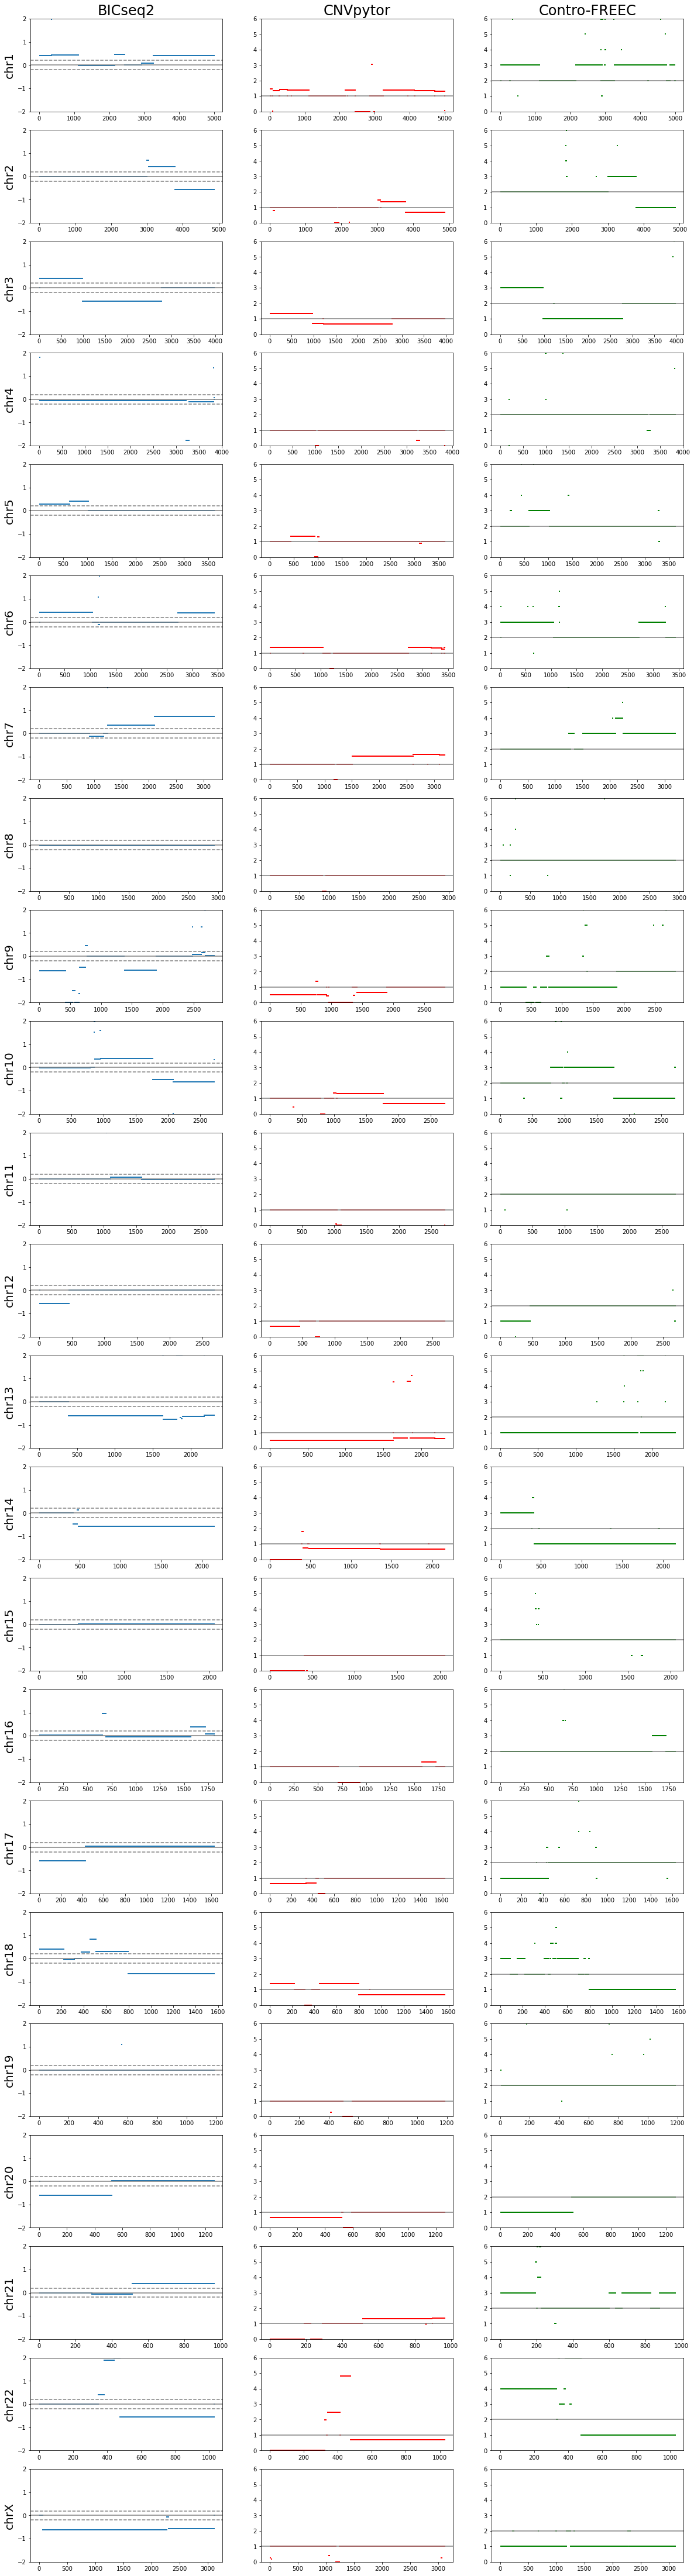

In [106]:
fig, ax = plt.subplots(len(chr_bin_number.keys()),3, figsize=(20,80))
for i, chr_ in enumerate(chr_bin_number.keys()):
    ax[i][0].scatter(range(0,len(BICseq_cnv_dict[chr_])), BICseq_cnv_dict[chr_], marker = ',', s=1)
    ax[i][0].set_ylim([-2, 2])
    ax[i][0].set_ylabel(chr_, fontsize=20)
    ax[i][0].axhline(y=0, color='grey')
    ax[i][0].axhline(y=0.2, color='grey',linestyle='--')
    ax[i][0].axhline(y=-0.2, color='grey',linestyle='--')
    
    ax[i][1].scatter(range(0,len(cnvpytor_cnv_dict[chr_])), cnvpytor_cnv_dict[chr_], color='red', marker = ',', s=1)
    ax[i][1].set_ylim([0, 6])
    ax[i][1].axhline(y=1, color='grey')

    ax[i][2].scatter(range(0,len(freec_cnv_dict[chr_])), freec_cnv_dict[chr_], color='green', marker = ',', s=1)
    ax[i][2].set_ylim([0, 6])
    ax[i][2].axhline(y=2, color='grey')

    if i == 0:
        ax[i][0].set_title("BICseq2",fontdict = {'fontsize':24})
        ax[i][1].set_title("CNVpytor",fontdict = {'fontsize':24})
        ax[i][2].set_title("Contro-FREEC",fontdict = {'fontsize':24})